In [1]:
# ============================================
# IPL Win Probability Predictor
# Day 6 — Cross Validation
# Addition 1 — Robust Model Evaluation
# ============================================
# GOAL: Replace single train/test split with 
# proper Group K-Fold cross validation to get
# statistically robust accuracy estimates

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold,cross_val_score,StratifiedKFold
from sklearn.metrics import accuracy_score
import xgboost as xgb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load model ready data
model_df = pd.read_csv("../data/model_ready_data.csv")
print("✅ Loaded model-ready data")
print("Shape:", model_df.shape)

✅ Loaded model-ready data
Shape: (83480, 10)


In [2]:
# One-hot encode team columns
model_df_encoded=pd.get_dummies(model_df,columns=['batting_team','bowling_team'])

# Store match_ids separately - needed for GroupKFold
match_ids=model_df_encoded['match_id'].values

# Features and target
X=model_df_encoded.drop(columns=['match_id','batting_team_won'])
y=model_df_encoded['batting_team_won']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Unique matches (groups):", len(np.unique(match_ids)))

Features shape: (83480, 32)
Target shape: (83480,)
Unique matches (groups): 724


In [3]:
# Set up Group K-Fold with 5 folds
gkf=GroupKFold(n_splits=5)

print("Number of folds:", gkf.get_n_splits())
print("\nVerifying fold sizes:")

for fold_number,(train_idx,test_idx) in enumerate(gkf.split(X,y,groups=match_ids)):
    train_matches=len(np.unique(match_ids[train_idx]))
    test_matches=len(np.unique(match_ids[test_idx]))
    print(f"Fold {fold_number+1}: Train matches={train_matches}, Test matches={test_matches}, Train rows={len(train_idx)}, Test rows={len(test_idx)}")

Number of folds: 5

Verifying fold sizes:
Fold 1: Train matches=579, Test matches=145, Train rows=66772, Test rows=16708
Fold 2: Train matches=580, Test matches=144, Train rows=66816, Test rows=16664
Fold 3: Train matches=579, Test matches=145, Train rows=66777, Test rows=16703
Fold 4: Train matches=579, Test matches=145, Train rows=66782, Test rows=16698
Fold 5: Train matches=579, Test matches=145, Train rows=66773, Test rows=16707


In [4]:
# Initialize both models
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42, 
                                eval_metric='logloss', verbosity=0)

# Store results
results = {
    'Random Forest': {'accuracies': [], 'model': rf_model},
    'XGBoost':       {'accuracies': [], 'model': xgb_model}
}

print("Running 5-Fold Cross Validation on BOTH models...")
print("=" * 55)

for fold_number,(train_idx,test_idx) in enumerate(gkf.split(X,y,groups=match_ids)):
    X_fold_train=X.iloc[train_idx]
    X_fold_test=X.iloc[test_idx]
    y_fold_train=y.iloc[train_idx]
    y_fold_test=y.iloc[test_idx]

    for model_name, model_info in results.items():

        model_info['model'].fit(X_fold_train,y_fold_train)
        predictions=model_info['model'].predict(X_fold_test)
        acc = accuracy_score(y_fold_test, predictions)
        model_info['accuracies'].append(acc)

    print(f"Fold {fold_number+1} complete ✅")


print("=" * 55)

# Print comparison
print("\nFINAL CROSS VALIDATION COMPARISON")
print("-" * 55)
print(f"{'Model':<20} {'Mean Acc':>10} {'Std Dev':>10} {'Min':>8} {'Max':>8}")
print("-" * 55)

for model_name, model_info in results.items():
    accs = model_info['accuracies']
    print(f"{model_name:<20} {np.mean(accs)*100:>9.2f}% {np.std(accs)*100:>9.2f}% {np.min(accs)*100:>7.2f}% {np.max(accs)*100:>7.2f}%")

print("-" * 55)
        

Running 5-Fold Cross Validation on BOTH models...
Fold 1 complete ✅
Fold 2 complete ✅
Fold 3 complete ✅
Fold 4 complete ✅
Fold 5 complete ✅

FINAL CROSS VALIDATION COMPARISON
-------------------------------------------------------
Model                  Mean Acc    Std Dev      Min      Max
-------------------------------------------------------
Random Forest            74.49%      2.68%   70.56%   78.80%
XGBoost                  73.90%      2.24%   71.02%   77.46%
-------------------------------------------------------


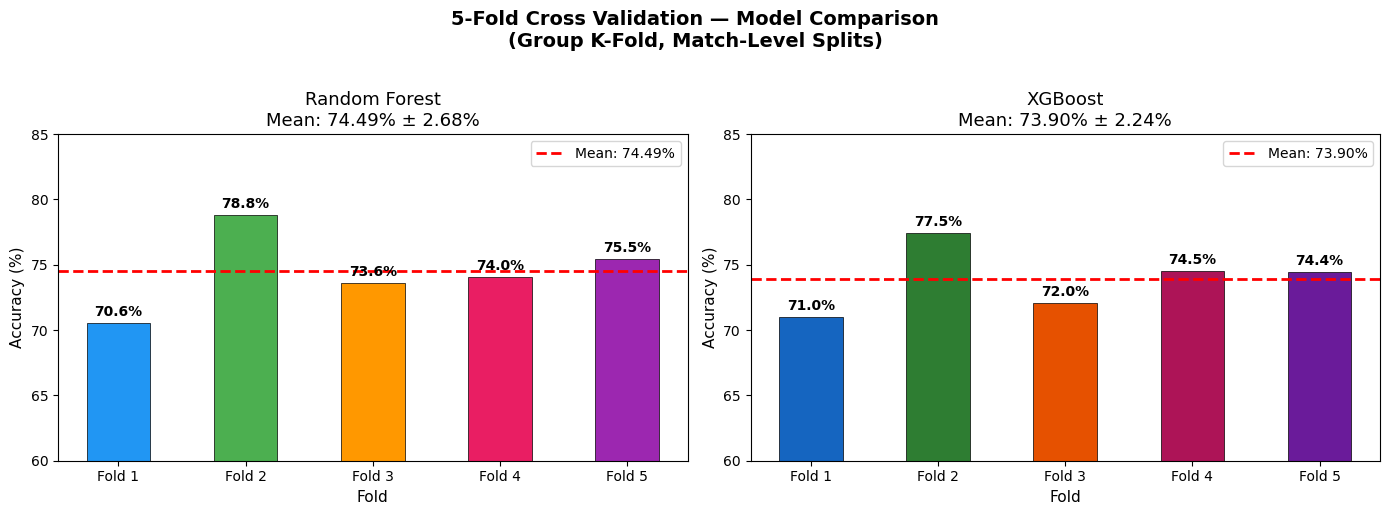

✅ Comparison chart saved


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_rf  = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']
colors_xgb = ['#1565C0', '#2E7D32', '#E65100', '#AD1457', '#6A1B9A']

for ax, (model_name, model_info), colors in zip(
    axes, results.items(), [colors_rf, colors_xgb]
):
    accs = model_info['accuracies']
    mean_acc = np.mean(accs) * 100

    bars = ax.bar(
        [f'Fold {i+1}' for i in range(5)],
        [a * 100 for a in accs],
        color=colors, width=0.5,
        edgecolor='black', linewidth=0.5
    )

    ax.axhline(y=mean_acc, color='red', linestyle='--',
               linewidth=2, label=f'Mean: {mean_acc:.2f}%')

    for bar, acc in zip(bars, accs):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{acc*100:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold'
        )

    ax.set_title(f'{model_name}\nMean: {mean_acc:.2f}% ± {np.std(accs)*100:.2f}%',
                 fontsize=13)
    ax.set_ylabel('Accuracy (%)', fontsize=11)
    ax.set_xlabel('Fold', fontsize=11)
    ax.set_ylim(60, 85)
    ax.legend(fontsize=10)

plt.suptitle('5-Fold Cross Validation — Model Comparison\n(Group K-Fold, Match-Level Splits)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../output/cv_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Comparison chart saved")

In [6]:
rf_mean  = np.mean(results['Random Forest']['accuracies'])
rf_std   = np.std(results['Random Forest']['accuracies'])
xgb_mean = np.mean(results['XGBoost']['accuracies'])
xgb_std  = np.std(results['XGBoost']['accuracies'])

print("FINAL MODEL SELECTION DECISION")
print("=" * 45)
print(f"Random Forest: {rf_mean*100:.2f}% ± {rf_std*100:.2f}%")
print(f"XGBoost:       {xgb_mean*100:.2f}% ± {xgb_std*100:.2f}%")
print("=" * 45)

# Decision logic - consider BOTH mean AND consistency (std)
mean_diff = abs(rf_mean - xgb_mean) * 100

if mean_diff < 1.0:
    print(f"\n⚠️  Difference in mean accuracy: {mean_diff:.2f}%")
    print("This difference is statistically negligible (<1%)")
    print("Choosing based on CONSISTENCY (lower std = more reliable):\n")
    
    if rf_std <= xgb_std:
        print("🏆 WINNER: Random Forest")
        print(f"   More consistent across folds (±{rf_std*100:.2f}% vs ±{xgb_std*100:.2f}%)")
        best_model_name = "Random Forest"
    else:
        print("🏆 WINNER: XGBoost")
        print(f"   More consistent across folds (±{xgb_std*100:.2f}% vs ±{rf_std*100:.2f}%)")
        best_model_name = "XGBoost"
else:
    if rf_mean > xgb_mean:
        print("🏆 WINNER: Random Forest (meaningfully higher accuracy)")
        best_model_name = "Random Forest"
    else:
        print("🏆 WINNER: XGBoost (meaningfully higher accuracy)")
        best_model_name = "XGBoost"

print(f"\nFinal model for Streamlit app: {best_model_name}")

FINAL MODEL SELECTION DECISION
Random Forest: 74.49% ± 2.68%
XGBoost:       73.90% ± 2.24%

⚠️  Difference in mean accuracy: 0.59%
This difference is statistically negligible (<1%)
Choosing based on CONSISTENCY (lower std = more reliable):

🏆 WINNER: XGBoost
   More consistent across folds (±2.24% vs ±2.68%)

Final model for Streamlit app: XGBoost


In [7]:
# Save cross validation results for README/documentation
cv_results = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(5)],
    'Random_Forest': [acc*100 for acc in results['Random Forest']['accuracies']],
    'XGBoost': [acc*100 for acc in results['XGBoost']['accuracies']]
})

cv_results.loc['Mean'] = ['Mean', 
    np.mean(results['Random Forest']['accuracies'])*100,
    np.mean(results['XGBoost']['accuracies'])*100
]

cv_results.to_csv('../output/cv_results.csv', index=False)
print("✅ Cross validation results saved")
print(cv_results)

✅ Cross validation results saved
        Fold  Random_Forest    XGBoost
0     Fold 1      70.564999  71.019871
1     Fold 2      78.798608  77.460394
2     Fold 3      73.591570  72.046938
3     Fold 4      74.044796  74.535873
4     Fold 5      75.471359  74.447836
Mean    Mean      74.494266  73.902182
